# 금융 데이터 다루기

# yfinance (Yahoo Finance API)
- 설명 : Yahoo Finance에서 주식 데이터를 가져오는 라이브러리
- 설치: `pip install yfinance`
- 주요 기능
    - 주식 정보 조회: 개별 주식의 과거 가격 데이터, 배당금 정보, 분할 정보 등을 조회할 수 있다.
    - 금융 데이터 다운로드: 일별, 주별, 월별 시계열 데이터를 Pandas DataFrame 형태로 쉽게 다운로드할 수 있다.
    - 다양한 금융 지표 제공: 시가, 고가, 저가, 종가, 거래량 등 주식 시장의 다양한 지표를 제공한다.
    - 복수 종목 데이터 동시 조회: 여러 주식 종목의 데이터를 한 번에 조회하는 기능을 지원한다.


## 1.1.yfinance 설치

- https://pypi.org/project/yfinance/

In [1]:
%pip install yfinance
# uv add yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
print(yf.__version__)

1.4.1


## 1.2.주식 데이터 가져오기

In [3]:
stock = yf.download('042700.KS', start='2022-01-01', end='2026-06-03')
stock = stock.reset_index()

stock.columns = stock.columns.droplevel(1)
stock.tail()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
1070,2026-05-27,319000.0,354000.0,312000.0,350500.0,1860431
1071,2026-05-28,292500.0,313000.0,284000.0,313000.0,1395171
1072,2026-05-29,282000.0,301000.0,277500.0,301000.0,1603208
1073,2026-06-01,293000.0,299000.0,285500.0,289500.0,1225560
1074,2026-06-02,275500.0,296500.0,273000.0,295500.0,1077612


In [4]:
stock.info()

<class 'pandas.DataFrame'>
RangeIndex: 1075 entries, 0 to 1074
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    1075 non-null   datetime64[s]
 1   Close   1075 non-null   float64      
 2   High    1075 non-null   float64      
 3   Low     1075 non-null   float64      
 4   Open    1075 non-null   float64      
 5   Volume  1075 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 50.5 KB


In [5]:
stock_info = yf.Ticker('042700.KS')
stock_info.info

{'address1': '14, Gajwa-ro 30 beon-gil',
 'address2': 'Seo-gu',
 'city': 'Incheon',
 'country': 'South Korea',
 'phone': '82 3 2571 9100',
 'fax': '82 3 2578 5557',
 'website': 'https://www.hanmisemi.com',
 'industry': 'Semiconductor Equipment & Materials',
 'industryKey': 'semiconductor-equipment-materials',
 'industryDisp': 'Semiconductor Equipment & Materials',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'HANMI Semiconductor Co., Ltd. manufactures and sells semiconductor equipment in South Korea and internationally. The company offers bonder; micro SAW equipment; vision placement equipment; meta grinder; EMI shield vision attach and detach, EMI shield vision placement, EMI shield tape mounter, EMI shield tape laser cutting, EMI shield tape demounter, vision inspection, and converlay attach equipment; laser marking, laser ablation, and laser cutting equipment; and pick and place, strip mounter, and vision inspection equipm

- 특정 기간의 주가 데이터 가져오기

In [6]:
# 최근 3년 데이터를 간단히 가져옴
# start, end로 기간을 지정하지 않아도 됨
stock1 = stock_info.history(period='3y')
stock1 = stock1.reset_index()
stock1

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2023-06-09 00:00:00+09:00,25502.221474,26536.095318,24960.668508,26191.470703,4478632,0.0,0.0
1,2023-06-12 00:00:00+09:00,26486.864534,26536.096624,25649.919001,26093.007812,1663874,0.0,0.0
2,2023-06-13 00:00:00+09:00,26929.952020,27422.272898,26043.774440,26191.470703,3954879,0.0,0.0
3,2023-06-14 00:00:00+09:00,26437.631430,27077.648578,25699.150105,25945.310547,3508721,0.0,0.0
4,2023-06-15 00:00:00+09:00,26585.328715,29145.397406,26388.400354,28702.308594,14530508,0.0,0.0
...,...,...,...,...,...,...,...,...
723,2026-06-02 00:00:00+09:00,295500.000000,296500.000000,273000.000000,275500.000000,1077612,0.0,0.0
724,2026-06-04 00:00:00+09:00,281000.000000,325000.000000,280000.000000,304000.000000,2395265,0.0,0.0
725,2026-06-05 00:00:00+09:00,294000.000000,298500.000000,278000.000000,283000.000000,967822,0.0,0.0
726,2026-06-08 00:00:00+09:00,250500.000000,275500.000000,250500.000000,253500.000000,954331,0.0,0.0


## 1.3.주가 데이터 시각화

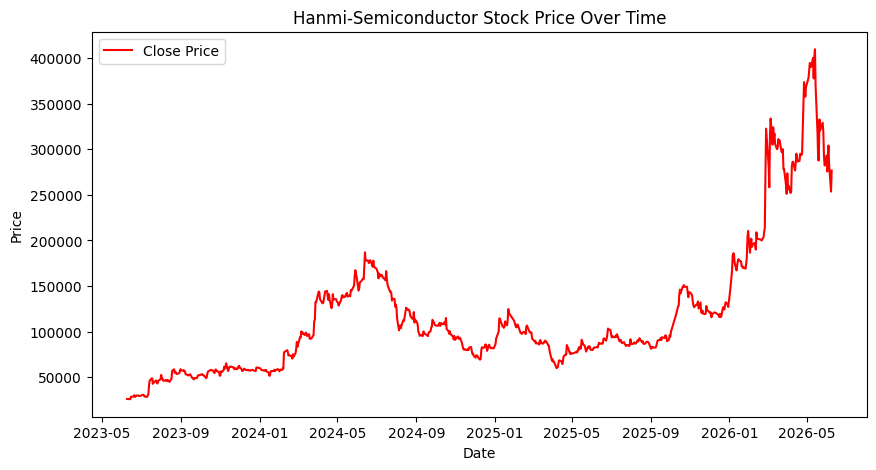

In [7]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
plt.plot(stock1['Date'], stock1['Close'], label='Close Price', color='red')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Hanmi-Semiconductor Stock Price Over Time')
plt.legend()
plt.show()

In [8]:
# 캔들 차트로 그리기
import plotly.graph_objects as go
import plotly.express as px



fig = go.Figure(data=[go.Candlestick(x=stock1['Date'],
                                     open=stock1['Open'],
                                     high=stock1['High'],
                                     low=stock1['Low'],
                                     close=stock1['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

## 1.4.LSTM으로 주식 예측하기

In [9]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

In [10]:
# 종가만 사용
close_prices = stock1['Close']
close_prices

0       26191.470703
1       26093.007812
2       26191.470703
3       25945.310547
4       28702.308594
           ...      
723    275500.000000
724    304000.000000
725    283000.000000
726    253500.000000
727    276500.000000
Name: Close, Length: 728, dtype: float64

In [11]:
# 데이터 스케일링
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices.values.reshape(-1, 1))

In [12]:
# 시퀀스 데이터 생성
sequence_length = 20
X, y = [], []

for i in range(len(scaled_data) - sequence_length):
    X.append(scaled_data[i:i+sequence_length])
    y.append(scaled_data[i+sequence_length])

X, y = np.array(X), np.array(y)

In [13]:
# 데이터 분할
# 시간 순서를 유지한 채로 앞 80%는 학습, 뒤 20% 테스트로 나눔.
# 시계열에서는 미래 데이터가 학습에 섞이지 않도록 무작위 분할을 피하는 것이 중요.
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [14]:
# 텐서 변환
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

In [15]:
# 데이터 로더 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [16]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    # 순전파 연산
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.linear(lstm_out[:,-1,:])

In [17]:
# 정의한 LSTMModel을 실제 모델 객체로 만들고 선택한 device로 이동
model = LSTMModel().to(device)

In [18]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

In [19]:
losses = []

# 모델 학습
model.train()
epochs = 30

for epoch in range(epochs):
    epoch_loss = 0  # 한 epoch 동안의 총 loss 저장
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)       # 손실 계산
        loss.backward()         # 역전파 수행
        optimizer.step()        # 가중치 업데이트
        epoch_loss += loss.item()       # 현재 배치의 손실값을 epoch_loss에 추가

    # 평균 loss
    avg_loss = epoch_loss / len(train_loader)       # 배치 개수로 나누어 평균 손실 계산
    losses.append(avg_loss)

    print(f'Epoch {epoch+1}/{epochs}, Loss : {avg_loss:.4f}')

Epoch 1/30, Loss : 0.0520
Epoch 2/30, Loss : 0.0422
Epoch 3/30, Loss : 0.0339
Epoch 4/30, Loss : 0.0265
Epoch 5/30, Loss : 0.0202
Epoch 6/30, Loss : 0.0151
Epoch 7/30, Loss : 0.0111
Epoch 8/30, Loss : 0.0083
Epoch 9/30, Loss : 0.0069
Epoch 10/30, Loss : 0.0062
Epoch 11/30, Loss : 0.0061
Epoch 12/30, Loss : 0.0060
Epoch 13/30, Loss : 0.0060
Epoch 14/30, Loss : 0.0059
Epoch 15/30, Loss : 0.0057
Epoch 16/30, Loss : 0.0057
Epoch 17/30, Loss : 0.0055
Epoch 18/30, Loss : 0.0054
Epoch 19/30, Loss : 0.0053
Epoch 20/30, Loss : 0.0051
Epoch 21/30, Loss : 0.0050
Epoch 22/30, Loss : 0.0049
Epoch 23/30, Loss : 0.0047
Epoch 24/30, Loss : 0.0045
Epoch 25/30, Loss : 0.0043
Epoch 26/30, Loss : 0.0041
Epoch 27/30, Loss : 0.0038
Epoch 28/30, Loss : 0.0035
Epoch 29/30, Loss : 0.0033
Epoch 30/30, Loss : 0.0029


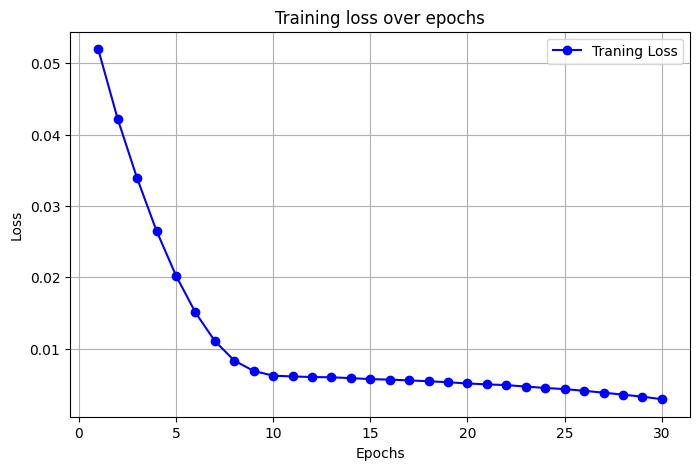

In [20]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), losses, marker='o', linestyle='-', color='b', label='Traning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training loss over epochs')
plt.legend()
plt.grid()
plt.show()

In [21]:
model.eval()                                        # 모델 평가모드로 변경
with torch.no_grad():                               # 그래디언트 계산 비활성화
    predicted = model(X_test_tensor).cpu().numpy()  # 테스트 데이터를 모델에 입력하여 예측 수행

In [22]:
# 예측값 스케일 복원
predicted_prices = scaler.inverse_transform(predicted)
real_prices = scaler.inverse_transform(y_test)

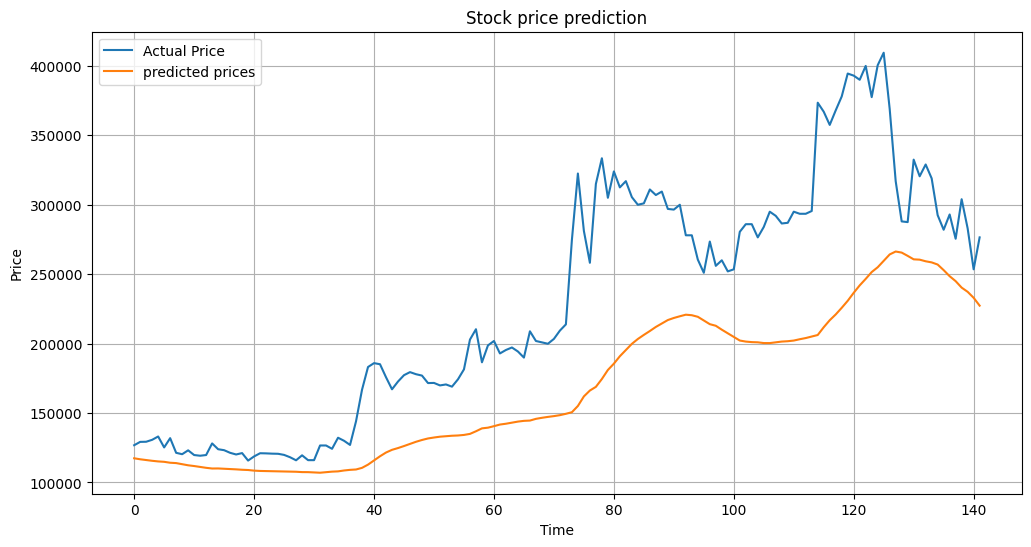

In [23]:
plt.figure(figsize=(12,6))
plt.plot(real_prices, label='Actual Price')
plt.plot(predicted_prices, label='predicted prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock price prediction')
plt.legend()
plt.grid()
plt.show()

In [24]:
# 미래 30일 예측을 위해 마지막 테스트 시퀀스를 시작점으로 사용.
future_days = 30

# 마지막 테스트 데이터를 기준으로 시작
recent_sequence = X_test_tensor[-1].cpu().numpy().tolist()

# 하루씩 예측한 값을 순서대로 저장
predictions = []
model.eval()

LSTMModel(
  (lstm): LSTM(1, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

In [25]:
# 자기회귀 방식으로 하루 예측하고, 그 예측값을 다시 다음 입력 시퀀스에 붙이고
# 먼 미래로 갈수록 실제 관측값이 아니라 이전 예측값에 의존하므로 오차가 누적될 수 있음.

with torch.no_grad():
    for _ in range(future_days):
        seq_tensor = torch.tensor(recent_sequence[-sequence_length:], dtype=torch.float32).unsqueeze(0).to(device)
        pred = model(seq_tensor).cpu().numpy()
        recent_sequence = np.append(recent_sequence, pred, axis=0)
        predictions.append(pred[0, 0])

# 스케일 역변환
predicted_future_prices = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# 1차원 배열로 변환
predicted_future_prices = predicted_future_prices.flatten()

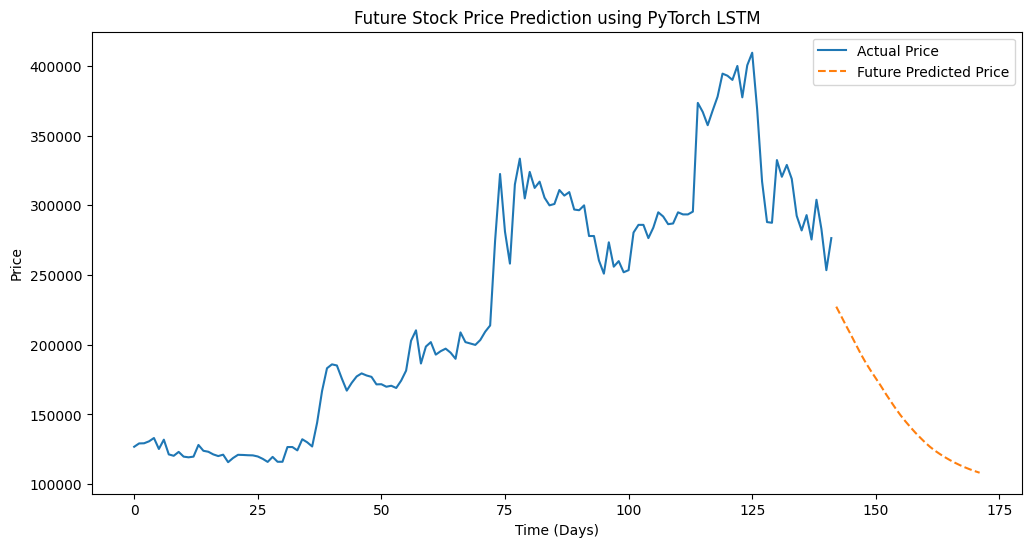

In [26]:
# 시각화
plt.figure(figsize=(12, 6))
plt.plot(real_prices, label='Actual Price')

# x축 인덱스 설정
plt.plot(range(len(real_prices), len(real_prices) + future_days),
         predicted_future_prices, label='Future Predicted Price', linestyle='--')

plt.title('Future Stock Price Prediction using PyTorch LSTM')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.legend()
plt.show()

In [27]:
import os
from importlib import resources
from prophet import Prophet
from prophet.models import CmdStanPyBackend
import warnings
warnings.filterwarnings('ignore')

def add_prophet_tbb_to_path():
    tbb_dir = resources.files('prophet') / 'stan_model' / f'cmdstan-{CmdStanPyBackend.CMDSTAN_VERSION}' / 'stan' / 'lib' / 'stan_math' / 'lib' / 'tbb'
    if not tbb_dir.exists():
        return None

    path_parts = os.environ.get('PATH', '').split(os.pathsep)
    if str(tbb_dir) not in path_parts:
        os.environ['PATH'] = str(tbb_dir) + os.pathsep + os.environ.get('PATH', '')
    os.environ['STAN_TBB'] = str(tbb_dir)
    return tbb_dir

add_prophet_tbb_to_path()

warnings.filterwarnings('ignore')

c:\Users\playdata2\work_space(playdata)\SKN30_playdata\LLM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
# Prophet은 입력 데이터 컬럼명을 반드시 ds, y로 요구
# ds : 날짜, y : 예측 대상 값(종가 close)
stock1 = stock1[['Date', 'Close']]
stock1.columns = ['ds', 'y']             # prophet에 맞게 컬럼명 변경

In [32]:
import pandas as pd
from prophet import Prophet

# stock1이 이미 ds/y를 가지고 있으면 그대로 복사
df_prophet = stock1.copy()

# ds가 없으면 index를 날짜로 보고 ds 생성
if "ds" not in df_prophet.columns:
    df_prophet = df_prophet.reset_index()
    df_prophet = df_prophet.rename(columns={df_prophet.columns[0]: "ds"})

# y가 없으면 Close를 y로 사용
if "y" not in df_prophet.columns:
    df_prophet = df_prophet.rename(columns={"Close": "y"})

# 중복 컬럼 제거
df_prophet = df_prophet.loc[:, ~df_prophet.columns.duplicated()]

# Prophet에 필요한 컬럼만 남기기
df_prophet = df_prophet[["ds", "y"]].dropna()

# timezone 제거
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], utc=True).dt.tz_convert(None)

add_prophet_tbb_to_path()

model = Prophet(yearly_seasonality=True, stan_backend="CMDSTANPY")
model.fit(df_prophet)

21:12:10 - cmdstanpy - INFO - Chain [1] start processing
21:12:11 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
# 미래 데이터 생성(예측기간 60일)
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

<Figure size 1200x600 with 0 Axes>

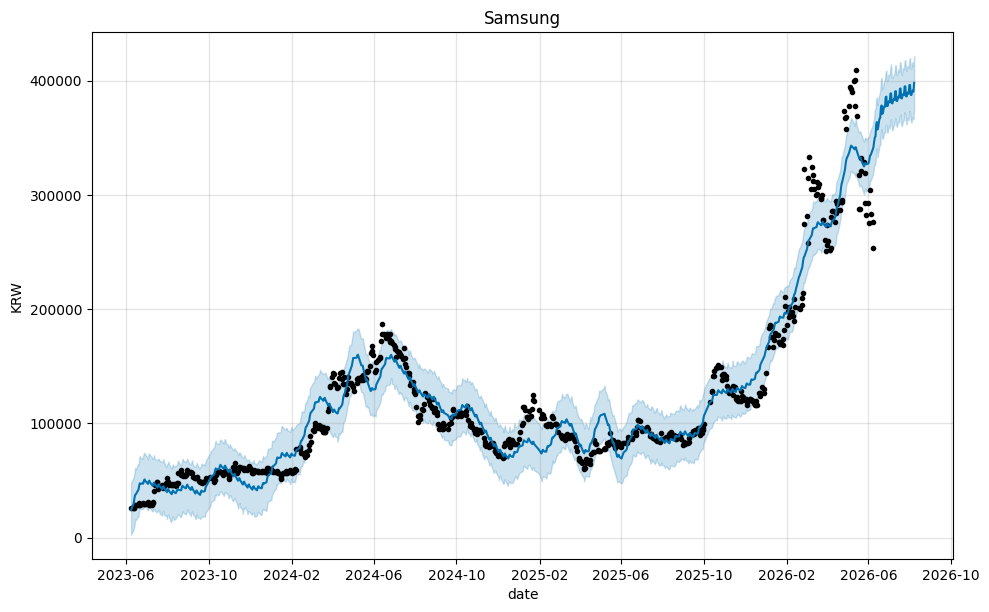

In [34]:
plt.figure(figsize=(12,6))
model.plot(forecast)            # prophet의 기본 plot으로 실제 데이터와 예측 추세를 함께 확인
plt.title('Samsung')
plt.xlabel('date')
plt.ylabel('KRW')
plt.show()

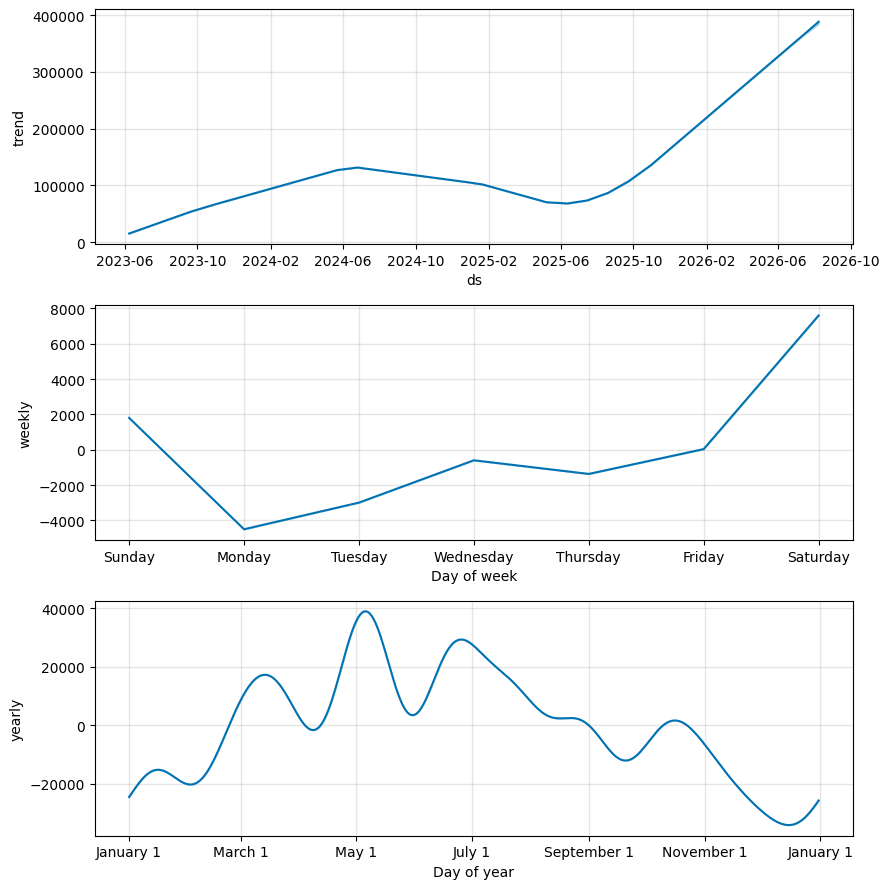

In [35]:
# 예측 결과를 추세와 계절성 구성 요소로 분해
# plot_components : 모델이 어떤 패턴을 근거로 예측했는지 해석할 때 유용
fig2 = model.plot_components(forecast)